# SST-Chlorophyll K-Means Clustering (June 2010 - November 2011)

This notebook combines MUR L4 SST and MODIS L2 chlorophyll data, projects them onto a common grid, and performs k-means clustering to identify oceanic regimes.

**Pipeline:**
1. Load SST data (MUR L4) and chlorophyll data (MODIS L2)
2. Project both onto a common lat/lon grid
3. Prepare feature vectors (SST, chlorophyll) for pixels with both measurements
4. Apply k-means clustering (k=3)
5. Visualize clusters on a map
6. Save processed data to E:\satdata\Custom

## 1. Setup and Imports

In [10]:
# Essential imports
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy.stats import binned_statistic_2d
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pickle
import cmocean

import sys
sys.dont_write_bytecode = True
sys.path.append(os.path.abspath(".."))

from pipelines.l3_pipeline import L3DatasetLoader
from pipelines.l2_pipeline import L2DatasetLoader, GPUDataExtractor

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Configuration

In [11]:
# Geographical bounds - Texas Louisiana Shelf
lon_min, lon_max = -94.0, -88.0
lat_min, lat_max = 27.5, 30.5

# Grid resolution
lat_bins = 200
lon_bins = 300

# Data paths - separate folders for each year
sst_base_pattern = r"E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_{year}-06-01_{year}-11-30"
chlor_base_pattern = r"E:\satdata\Texas Louisiana Shelf_{year}-06-01_{year}-11-30"
output_dir = r"E:\satdata\Custom"

# Variables
sst_var = 'analysed_sst'
chlor_var = 'chlor_a'
chlor_group = 'geophysical_data'

# Clustering
n_clusters = 3

# Years
years = [2010, 2011]

print(f"Region: [{lon_min}, {lat_min}] to [{lon_max}, {lat_max}]")
print(f"Grid: {lat_bins} x {lon_bins} bins")
print(f"Output directory: {output_dir}")
print(f"Number of clusters: {n_clusters}")
print(f"Years: {years}")

Region: [-94.0, 27.5] to [-88.0, 30.5]
Grid: 200 x 300 bins
Output directory: E:\satdata\Custom
Number of clusters: 3
Years: [2010, 2011]


## 3. Load SST Data (MUR L4)

In [12]:
# Find SST files from both years
sst_files = []
for year in years:
    sst_dir = sst_base_pattern.format(year=year)
    year_files = glob.glob(os.path.join(sst_dir, '*.nc'))
    sst_files.extend(year_files)
    print(f"Year {year}: Found {len(year_files)} SST files in {sst_dir}")

sst_files = sorted(sst_files)

if not sst_files:
    raise FileNotFoundError(f"No SST files found. Check directories for years {years}")
else:
    print(f"\nTotal: Found {len(sst_files)} SST files")

# Load SST datasets
sst_loader = L3DatasetLoader(variables=[sst_var], bbox=(lon_min, lon_max, lat_min, lat_max))

if sst_files:
    try:
        sst_datasets = sst_loader.load_multiple(sst_files)
        print(f"Successfully loaded {len(sst_datasets)} SST datasets")
        
        if not sst_datasets:
            raise ValueError("No datasets were successfully loaded. Check file paths and variable names.")
        
        # Get lat/lon from first dataset (MUR L4 has consistent grid for all days)
        lat_sst = sst_datasets[0]['lat'].values
        lon_sst = sst_datasets[0]['lon'].values
        print(f"SST grid: lat {lat_sst.shape}, lon {lon_sst.shape}")
        
        # Verify grid consistency (optional check)
        if len(sst_datasets) > 1:
            lat_check = sst_datasets[-1]['lat'].values
            lon_check = sst_datasets[-1]['lon'].values
            if np.array_equal(lat_sst, lat_check) and np.array_equal(lon_sst, lon_check):
                print("✓ Grid consistency verified (first and last file match)")
            else:
                print("⚠ Warning: Grid mismatch detected!")
        
        # Extract and process SST data, then average
        sst_list = []
        for i, ds in enumerate(sst_datasets):
            sst_kelvin = ds[sst_var].values.squeeze()  # Remove time dimension
            sst_celsius = sst_kelvin - 273.15
            # Quality control
            sst_celsius[(sst_celsius < -2) | (sst_celsius > 35)] = np.nan
            sst_list.append(sst_celsius)
            
            if i % 100 == 0:
                print(f"Processed {i+1}/{len(sst_datasets)} SST files...")
        
        # Average all SST data (temporal mean)
        sst_stack = np.stack(sst_list, axis=0)
        sst_mean = np.nanmean(sst_stack, axis=0)
        
        print(f"\nSST grid shape: {sst_mean.shape}")
        print(f"SST range: {np.nanmin(sst_mean):.2f} to {np.nanmax(sst_mean):.2f} °C")
        print(f"Valid SST pixels: {np.sum(~np.isnan(sst_mean))}")
        
    except Exception as e:
        print(f"Error loading SST datasets: {e}")
        raise
else:
    raise FileNotFoundError("No SST files found to load")

Year 2010: Found 184 SST files in E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_2010-06-01_2010-11-30
Year 2011: Found 184 SST files in E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_2011-06-01_2011-11-30

Total: Found 368 SST files
Successfully loaded 368 SST datasets
SST grid: lat (301,), lon (601,)
✓ Grid consistency verified (first and last file match)
Processed 1/368 SST files...
Successfully loaded 368 SST datasets
SST grid: lat (301,), lon (601,)
✓ Grid consistency verified (first and last file match)
Processed 1/368 SST files...
Processed 101/368 SST files...
Processed 101/368 SST files...
Processed 201/368 SST files...
Processed 201/368 SST files...
Processed 301/368 SST files...
Processed 301/368 SST files...

SST grid shape: (301, 601)
SST range: 26.67 to 28.71 °C
Valid SST pixels: 137002

SST grid shape: (301, 601)
SST range: 26.67 to 28.71 °C
Valid SST pixels: 137002


## 4. Load Chlorophyll Data (MODIS L2)

In [13]:
# Find chlorophyll files
chlor_files = []
for year in years:
    chlor_dir = chlor_base_pattern.format(year=year)
    year_files = glob.glob(os.path.join(chlor_dir, '**', '*.nc'), recursive=True)
    chlor_files.extend(year_files)

print(f"Found {len(chlor_files)} chlorophyll files")

# Limit for testing (remove for full processing)
# chlor_files = chlor_files[:50]
# print(f"Using {len(chlor_files)} files for processing")

# Load chlorophyll datasets
chlor_loader = L2DatasetLoader(variables=[chlor_var], group=chlor_group)
chlor_datasets = chlor_loader.load_multiple(chlor_files)
print(f"Loaded {len(chlor_datasets)} chlorophyll datasets")

Found 586 chlorophyll files
Loaded 586 chlorophyll datasets
Loaded 586 chlorophyll datasets


In [14]:
# Extract chlorophyll data
try:
    print("Attempting GPU extraction...")
    extractor = GPUDataExtractor(variables=[chlor_var])
    lon_chlor_flat, lat_chlor_flat, chlor_data = extractor.extract(chlor_datasets)
    chlor_flat = chlor_data[chlor_var]
    print(f"✓ GPU extraction: {len(chlor_flat)} points")
except Exception as e:
    print(f"GPU failed: {e}. Using CPU...")
    all_lons, all_lats, all_chlor = [], [], []
    for i, ds in enumerate(chlor_datasets):
        if i % 50 == 0:
            print(f"Processing {i+1}/{len(chlor_datasets)}...")
        lat = ds['lat'].values.flatten()
        lon = ds['lon'].values.flatten()
        chlor = ds[chlor_var].values.flatten()
        valid = (~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(chlor) & (chlor > 0))
        all_lats.extend(lat[valid])
        all_lons.extend(lon[valid])
        all_chlor.extend(chlor[valid])
    lat_chlor_flat = np.array(all_lats)
    lon_chlor_flat = np.array(all_lons)
    chlor_flat = np.array(all_chlor)
    print(f"✓ CPU extraction: {len(chlor_flat)} points")

print(f"Chlorophyll range: {np.min(chlor_flat):.6f} to {np.max(chlor_flat):.6f} mg/m³")

Attempting GPU extraction...
✓ GPU extraction: 234776489 points
Chlorophyll range: 0.001000 to 86.378639 mg/m³
✓ GPU extraction: 234776489 points
Chlorophyll range: 0.001000 to 86.378639 mg/m³


## 5. Project Chlorophyll onto Common Grid

In [15]:
# Clip chlorophyll to bounding box
clip_mask = ((lon_chlor_flat >= lon_min) & (lon_chlor_flat <= lon_max) &
             (lat_chlor_flat >= lat_min) & (lat_chlor_flat <= lat_max))

lon_clipped = lon_chlor_flat[clip_mask]
lat_clipped = lat_chlor_flat[clip_mask]
chlor_clipped = chlor_flat[clip_mask]

print(f"Chlorophyll points in region: {len(chlor_clipped)}")

# Bin chlorophyll onto grid
chlor_binned, lat_edges, lon_edges, _ = binned_statistic_2d(
    lat_clipped, lon_clipped, chlor_clipped,
    statistic='mean',
    bins=[lat_bins, lon_bins],
    range=[[lat_min, lat_max], [lon_min, lon_max]]
)

print(f"Chlorophyll grid shape: {chlor_binned.shape}")
print(f"Valid chlorophyll pixels: {np.sum(~np.isnan(chlor_binned))}")

Chlorophyll points in region: 12630754
Chlorophyll grid shape: (200, 300)
Valid chlorophyll pixels: 46406
Chlorophyll grid shape: (200, 300)
Valid chlorophyll pixels: 46406


## 6. Align SST to Chlorophyll Grid

In [16]:
# Resample SST to match chlorophyll grid
from scipy.interpolate import RegularGridInterpolator

# Create interpolator for SST
sst_interpolator = RegularGridInterpolator(
    (lat_sst, lon_sst), 
    sst_mean,
    method='linear',
    bounds_error=False,
    fill_value=np.nan
)

# Create target grid (bin centers)
lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)

# Interpolate SST to chlorophyll grid
points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
sst_regridded = sst_interpolator(points).reshape(chlor_binned.shape)

print(f"Regridded SST shape: {sst_regridded.shape}")
print(f"Valid SST pixels after regridding: {np.sum(~np.isnan(sst_regridded))}")
print(f"SST range: {np.nanmin(sst_regridded):.2f} to {np.nanmax(sst_regridded):.2f} °C")

Regridded SST shape: (200, 300)
Valid SST pixels after regridding: 44898
SST range: 26.68 to 28.71 °C


## 7. Prepare Data for Clustering

In [17]:
# Create mask for pixels with both SST and chlorophyll
valid_mask = ~np.isnan(sst_regridded) & ~np.isnan(chlor_binned)
n_valid = np.sum(valid_mask)

print(f"Pixels with both SST and chlorophyll: {n_valid}")

# Extract valid pixels
sst_valid = sst_regridded[valid_mask]
chlor_valid = chlor_binned[valid_mask]

# Create feature matrix (N x 2)
features = np.column_stack([sst_valid, np.log10(chlor_valid)])  # Log-transform chlorophyll

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(f"Feature matrix shape: {features_scaled.shape}")
print(f"SST mean: {sst_valid.mean():.2f} °C, std: {sst_valid.std():.2f}")
print(f"Chlorophyll mean: {chlor_valid.mean():.6f} mg/m³, std: {chlor_valid.std():.6f}")

Pixels with both SST and chlorophyll: 44680
Feature matrix shape: (44680, 2)
SST mean: 28.15 °C, std: 0.49
Chlorophyll mean: 3.390938 mg/m³, std: 5.147958


## 8. K-Means Clustering

In [18]:
# Perform k-means clustering
print(f"Running k-means with {n_clusters} clusters...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_scaled)

print(f"✓ Clustering complete")
print(f"Cluster centers (scaled):")
print(kmeans.cluster_centers_)

# Transform back to original scale
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print(f"\nCluster centers (original):")
for i, center in enumerate(centers_original):
    print(f"  Cluster {i}: SST={center[0]:.2f}°C, Chlor={10**center[1]:.6f} mg/m³")

# Count pixels per cluster
print(f"\nPixels per cluster:")
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    print(f"  Cluster {i}: {count} pixels ({100*count/n_valid:.1f}%)")

Running k-means with 3 clusters...
✓ Clustering complete
Cluster centers (scaled):
[[ 0.76564465 -0.89378825]
 [-1.68042741  1.42815024]
 [-0.08932346  0.45098454]]

Cluster centers (original):
  Cluster 0: SST=28.52°C, Chlor=0.290703 mg/m³
  Cluster 1: SST=27.33°C, Chlor=10.304591 mg/m³
  Cluster 2: SST=28.11°C, Chlor=2.295642 mg/m³

Pixels per cluster:
  Cluster 0: 21583 pixels (48.3%)
  Cluster 1: 9072 pixels (20.3%)
  Cluster 2: 14025 pixels (31.4%)
✓ Clustering complete
Cluster centers (scaled):
[[ 0.76564465 -0.89378825]
 [-1.68042741  1.42815024]
 [-0.08932346  0.45098454]]

Cluster centers (original):
  Cluster 0: SST=28.52°C, Chlor=0.290703 mg/m³
  Cluster 1: SST=27.33°C, Chlor=10.304591 mg/m³
  Cluster 2: SST=28.11°C, Chlor=2.295642 mg/m³

Pixels per cluster:
  Cluster 0: 21583 pixels (48.3%)
  Cluster 1: 9072 pixels (20.3%)
  Cluster 2: 14025 pixels (31.4%)


## 9. Create Cluster Map

In [19]:
# Create 2D cluster map
cluster_map = np.full(sst_regridded.shape, np.nan)
cluster_map[valid_mask] = cluster_labels

print(f"Cluster map shape: {cluster_map.shape}")
print(f"Valid cluster assignments: {np.sum(~np.isnan(cluster_map))}")

Cluster map shape: (200, 300)
Valid cluster assignments: 44680


## 10. Save Results

In [20]:
# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save results as pickle
results = {
    'sst_grid': sst_regridded,
    'chlor_grid': chlor_binned,
    'cluster_map': cluster_map,
    'cluster_labels': cluster_labels,
    'cluster_centers': centers_original,
    'kmeans_model': kmeans,
    'scaler': scaler,
    'lat_centers': lat_centers,
    'lon_centers': lon_centers,
    'lat_edges': lat_edges,
    'lon_edges': lon_edges,
    'valid_mask': valid_mask,
    'n_clusters': n_clusters,
    'bbox': (lon_min, lon_max, lat_min, lat_max)
}

output_file = os.path.join(output_dir, 'sst_chlorophyll_clusters_2010_2011.pkl')
with open(output_file, 'wb') as f:
    pickle.dump(results, f)

print(f"✓ Results saved to: {output_file}")
print(f"File size: {os.path.getsize(output_file) / 1e6:.2f} MB")

✓ Results saved to: E:\satdata\Custom\sst_chlorophyll_clusters_2010_2011.pkl
File size: 1.68 MB


## 11. Visualization: Cluster Map

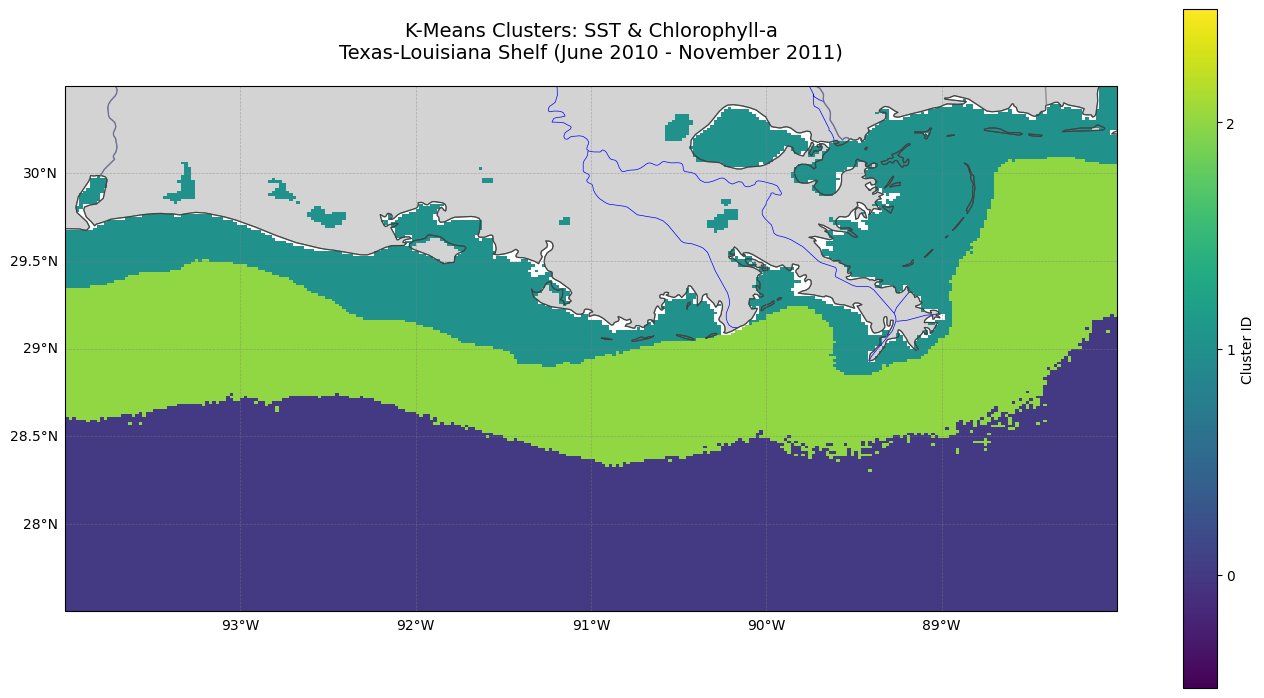


Cluster characteristics:

Cluster 0:
  SST: 28.52 ± 0.08 °C
  Chlorophyll: 0.346503 ± 0.223787 mg/m³
  Pixels: 21583 (48.3%)

Cluster 1:
  SST: 27.33 ± 0.29 °C
  Chlorophyll: 11.613653 ± 5.923209 mg/m³
  Pixels: 9072 (20.3%)

Cluster 2:
  SST: 28.11 ± 0.21 °C
  Chlorophyll: 2.757180 ± 1.804262 mg/m³
  Pixels: 14025 (31.4%)


In [21]:
# Create cluster map visualization
fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Plot clusters with discrete colors
cluster_plot = ax.pcolormesh(
    lon_edges, lat_edges, cluster_map,
    cmap='viridis', shading='auto',
    transform=ccrs.PlateCarree(),
    vmin=-0.5, vmax=n_clusters-0.5
)

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue')
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)

# Gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Colorbar
cbar = plt.colorbar(cluster_plot, ax=ax, label='Cluster ID', 
                    ticks=range(n_clusters), shrink=0.7)

plt.title('K-Means Clusters: SST & Chlorophyll-a\nTexas-Louisiana Shelf (June 2010 - November 2011)', 
          fontsize=14, pad=20)

plt.tight_layout()
plt.show()

print("\nCluster characteristics:")
for i in range(n_clusters):
    mask = cluster_labels == i
    print(f"\nCluster {i}:")
    print(f"  SST: {sst_valid[mask].mean():.2f} ± {sst_valid[mask].std():.2f} °C")
    print(f"  Chlorophyll: {chlor_valid[mask].mean():.6f} ± {chlor_valid[mask].std():.6f} mg/m³")
    print(f"  Pixels: {mask.sum()} ({100*mask.sum()/len(mask):.1f}%)")

## 12. Multi-Panel Visualization

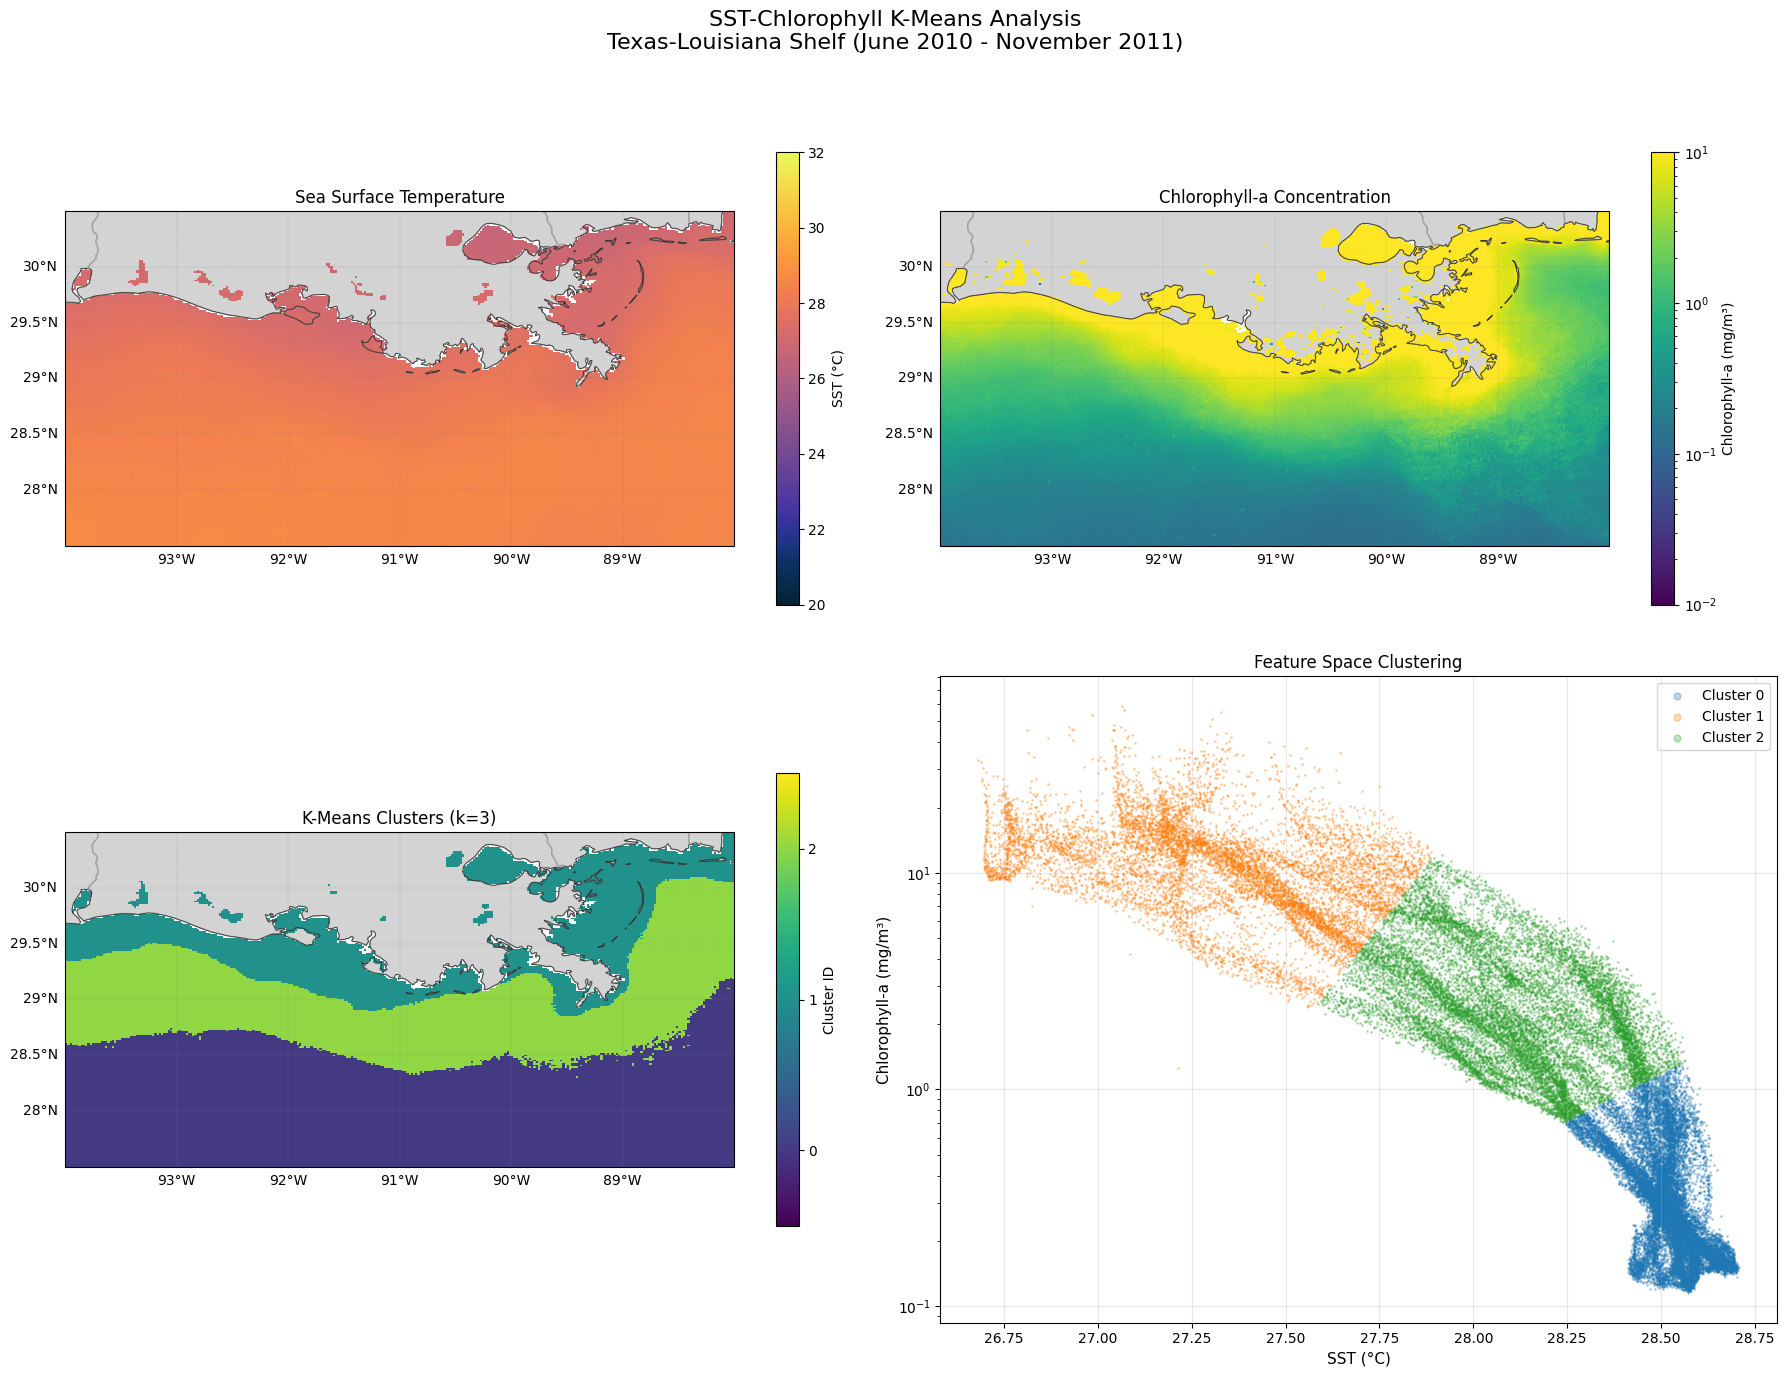

In [22]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14), 
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Set extent for all subplots
for ax in axes:
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# 1. SST
sst_plot = axes[0].pcolormesh(lon_edges, lat_edges, sst_regridded,
                              cmap=cmocean.cm.thermal, shading='auto',
                              transform=ccrs.PlateCarree(), vmin=20, vmax=32)
plt.colorbar(sst_plot, ax=axes[0], label='SST (°C)', shrink=0.7)
axes[0].set_title('Sea Surface Temperature', fontsize=12)

# 2. Chlorophyll (log scale)
import matplotlib.colors as colors
chlor_plot = axes[1].pcolormesh(lon_edges, lat_edges, chlor_binned,
                                cmap='viridis', shading='auto',
                                transform=ccrs.PlateCarree(),
                                norm=colors.LogNorm(vmin=0.01, vmax=10))
plt.colorbar(chlor_plot, ax=axes[1], label='Chlorophyll-a (mg/m³)', shrink=0.7)
axes[1].set_title('Chlorophyll-a Concentration', fontsize=12)

# 3. Clusters
cluster_plot = axes[2].pcolormesh(lon_edges, lat_edges, cluster_map,
                                  cmap='viridis', shading='auto',
                                  transform=ccrs.PlateCarree(),
                                  vmin=-0.5, vmax=n_clusters-0.5)
plt.colorbar(cluster_plot, ax=axes[2], label='Cluster ID', 
             ticks=range(n_clusters), shrink=0.7)
axes[2].set_title('K-Means Clusters (k=3)', fontsize=12)

# 4. Scatter plot of features colored by cluster
axes[3].remove()
ax_scatter = fig.add_subplot(2, 2, 4)
for i in range(n_clusters):
    mask = cluster_labels == i
    ax_scatter.scatter(sst_valid[mask], chlor_valid[mask], 
                      alpha=0.3, s=1, label=f'Cluster {i}')
ax_scatter.set_xlabel('SST (°C)', fontsize=11)
ax_scatter.set_ylabel('Chlorophyll-a (mg/m³)', fontsize=11)
ax_scatter.set_yscale('log')
ax_scatter.set_title('Feature Space Clustering', fontsize=12)
ax_scatter.legend(markerscale=5)
ax_scatter.grid(True, alpha=0.3)

# Add map features to geographic plots
for ax in axes[:3]:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='black')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.4)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                     linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

plt.suptitle('SST-Chlorophyll K-Means Analysis\nTexas-Louisiana Shelf (June 2010 - November 2011)',
             fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## 13. Feature Space Visualization (SST vs Chlorophyll)

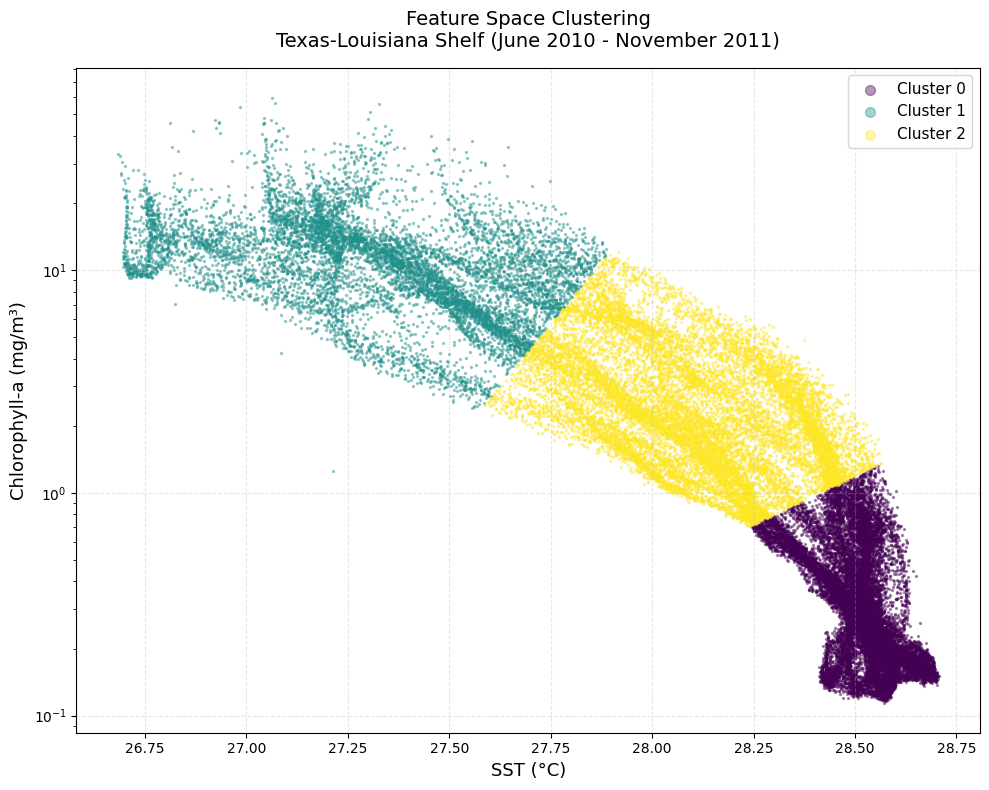


Feature space statistics:
SST range: 26.68 - 28.71 °C
Chlorophyll range: 0.114499 - 59.115369 mg/m³
Total data points: 44,680


In [23]:
# Create standalone feature space scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot each cluster with different colors
colors_palette = plt.cm.viridis(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = cluster_labels == i
    ax.scatter(sst_valid[mask], chlor_valid[mask], 
              alpha=0.4, s=2, 
              color=colors_palette[i],
              label=f'Cluster {i}')

ax.set_xlabel('SST (°C)', fontsize=13)
ax.set_ylabel('Chlorophyll-a (mg/m³)', fontsize=13)
ax.set_yscale('log')
ax.set_title('Feature Space Clustering\nTexas-Louisiana Shelf (June 2010 - November 2011)', 
             fontsize=14, pad=15)
ax.legend(markerscale=5, fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\nFeature space statistics:")
print(f"SST range: {sst_valid.min():.2f} - {sst_valid.max():.2f} °C")
print(f"Chlorophyll range: {chlor_valid.min():.6f} - {chlor_valid.max():.6f} mg/m³")
print(f"Total data points: {len(sst_valid):,}")